In [5]:
import pandas as pd
import numpy as np

# Load the VCDB dataset
df = pd.read_csv("vcdb.csv", low_memory=False)

# Basic information
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Display first 5 records
print(df.head())

Rows: 10596
Columns: 2683
  action.environmental.notes  action.environmental.variety.Deterioration  \
0                        NaN                                       False   
1                        NaN                                       False   
2                        NaN                                       False   
3                        NaN                                       False   
4                        NaN                                       False   

   action.environmental.variety.Earthquake  action.environmental.variety.EMI  \
0                                    False                             False   
1                                    False                             False   
2                                    False                             False   
3                                    False                             False   
4                                    False                             False   

   action.environmental.variety.ESD 

In [6]:
# See all column names
for i, col in enumerate(df.columns):
    print(i, col)

0 action.environmental.notes
1 action.environmental.variety.Deterioration
2 action.environmental.variety.Earthquake
3 action.environmental.variety.EMI
4 action.environmental.variety.ESD
5 action.environmental.variety.Fire
6 action.environmental.variety.Flood
7 action.environmental.variety.Hazmat
8 action.environmental.variety.Humidity
9 action.environmental.variety.Hurricane
10 action.environmental.variety.Ice
11 action.environmental.variety.Landslide
12 action.environmental.variety.Leak
13 action.environmental.variety.Lightning
14 action.environmental.variety.Meteorite
15 action.environmental.variety.Other
16 action.environmental.variety.Particulates
17 action.environmental.variety.Pathogen
18 action.environmental.variety.Power failure
19 action.environmental.variety.Temperature
20 action.environmental.variety.Tornado
21 action.environmental.variety.Tsunami
22 action.environmental.variety.Unknown
23 action.environmental.variety.Vermin
24 action.environmental.variety.Volcano
25 action.

In [7]:
# Check missing values
missing = df.isnull().sum()

print(missing.sort_values(ascending=False).head(30))
df.info()

asset.assets.amount.U - Unknown             10596
impact.loss.max_amount                      10596
asset.assets.amount.N - Public WAN          10596
asset.assets.amount.S - LLM application     10596
asset.assets.amount.N - Private WAN         10596
asset.assets.amount.P - Developer           10596
asset.assets.amount.S - DNS                 10596
asset.assets.amount.P - Partner             10596
asset.assets.amount.N - PBX                 10596
asset.assets.amount.U - VoIP phone          10596
asset.assets.amount.N - Other               10596
asset.assets.amount.N - NAS                 10596
asset.assets.amount.N - LAN                 10596
asset.assets.amount.N - IDS                 10596
asset.assets.amount.S - DHCP                10596
asset.assets.amount.N - Broadband           10596
asset.assets.amount.N - Access reader       10596
asset.assets.amount.U - Peripheral          10596
asset.assets.amount.N - Remote access       10596
asset.assets.amount.N - Router or switch    10596


In [8]:
column_summary = pd.DataFrame({
    "Column": df.columns,
    "Non_Null": df.notna().sum().values,
    "Unique_Values": df.nunique(dropna=True).values
})

column_summary = column_summary.sort_values(
    "Non_Null", ascending=False
)

column_summary.head(50)

,Column,Non_Null,Unique_Values
1341,asset.country.ST,10596,1
1730,impact.iso_currency_code.ZMK,10596,1
1760,plus.analysis_status.Finalized,10596,2
1761,plus.analysis_status.First pass,10596,2
1762,plus.analysis_status.In-progress,10596,1
1763,plus.analysis_status.Ineligible,10596,2
1764,plus.analysis_status.Ready for review,10596,2
1765,plus.analysis_status.Reviewed,10596,2
1768,plus.asset_os.Android,10596,2
1769,plus.asset_os.Apple iOS,10596,2


In [9]:
# Search for important cybersecurity-related columns

keywords = [
    "action",
    "asset",
    "actor",
    "attribute",
    "discovery",
    "impact",
    "vulnerability",
    "confidentiality",
    "integrity",
    "availability"
]

matching_columns = []

for col in df.columns:
    if any(keyword in col.lower() for keyword in keywords):
        matching_columns.append(col)

print("Number of matching columns:", len(matching_columns))

for col in matching_columns:
    print(col)

Number of matching columns: 1830
action.environmental.notes
action.environmental.variety.Deterioration
action.environmental.variety.Earthquake
action.environmental.variety.EMI
action.environmental.variety.ESD
action.environmental.variety.Fire
action.environmental.variety.Flood
action.environmental.variety.Hazmat
action.environmental.variety.Humidity
action.environmental.variety.Hurricane
action.environmental.variety.Ice
action.environmental.variety.Landslide
action.environmental.variety.Leak
action.environmental.variety.Lightning
action.environmental.variety.Meteorite
action.environmental.variety.Other
action.environmental.variety.Particulates
action.environmental.variety.Pathogen
action.environmental.variety.Power failure
action.environmental.variety.Temperature
action.environmental.variety.Tornado
action.environmental.variety.Tsunami
action.environmental.variety.Unknown
action.environmental.variety.Vermin
action.environmental.variety.Volcano
action.environmental.variety.Wind
action.e

In [10]:
action_columns = [
    col for col in df.columns
    if col.lower().startswith("action.")
]

print("Action-related columns:", len(action_columns))

for col in action_columns:
    print(col)

Action-related columns: 347
action.environmental.notes
action.environmental.variety.Deterioration
action.environmental.variety.Earthquake
action.environmental.variety.EMI
action.environmental.variety.ESD
action.environmental.variety.Fire
action.environmental.variety.Flood
action.environmental.variety.Hazmat
action.environmental.variety.Humidity
action.environmental.variety.Hurricane
action.environmental.variety.Ice
action.environmental.variety.Landslide
action.environmental.variety.Leak
action.environmental.variety.Lightning
action.environmental.variety.Meteorite
action.environmental.variety.Other
action.environmental.variety.Particulates
action.environmental.variety.Pathogen
action.environmental.variety.Power failure
action.environmental.variety.Temperature
action.environmental.variety.Tornado
action.environmental.variety.Tsunami
action.environmental.variety.Unknown
action.environmental.variety.Vermin
action.environmental.variety.Volcano
action.environmental.variety.Wind
action.error.

In [11]:
asset_columns = [
    col for col in df.columns
    if col.lower().startswith("asset.")
]

print("Asset-related columns:", len(asset_columns))

for col in asset_columns:
    print(col)

Asset-related columns: 494
asset.assets.amount.E - Other
asset.assets.amount.E - Telematics
asset.assets.amount.E - Telemetry
asset.assets.amount.E - Unknown
asset.assets.amount.M - Disk drive
asset.assets.amount.M - Disk media
asset.assets.amount.M - Documents
asset.assets.amount.M - Fax
asset.assets.amount.M - Flash drive
asset.assets.amount.M - Other
asset.assets.amount.M - Payment card
asset.assets.amount.M - SIM card
asset.assets.amount.M - Smart card
asset.assets.amount.M - Tapes
asset.assets.amount.M - Unknown
asset.assets.amount.N - Access reader
asset.assets.amount.N - Broadband
asset.assets.amount.N - Camera
asset.assets.amount.N - Firewall
asset.assets.amount.N - IDS
asset.assets.amount.N - LAN
asset.assets.amount.N - NAS
asset.assets.amount.N - Other
asset.assets.amount.N - PBX
asset.assets.amount.N - PLC
asset.assets.amount.N - Private WAN
asset.assets.amount.N - Public WAN
asset.assets.amount.N - Remote access
asset.assets.amount.N - Router or switch
asset.assets.amount.N

In [12]:
actor_columns = [
    col for col in df.columns
    if col.lower().startswith("actor.")
]

print("Actor-related columns:", len(actor_columns))

for col in actor_columns:
    print(col)

Actor-related columns: 595
actor.external.country.AD
actor.external.country.AE
actor.external.country.AF
actor.external.country.AG
actor.external.country.AI
actor.external.country.AL
actor.external.country.AM
actor.external.country.AO
actor.external.country.AQ
actor.external.country.AR
actor.external.country.AS
actor.external.country.AT
actor.external.country.AU
actor.external.country.AW
actor.external.country.AX
actor.external.country.AZ
actor.external.country.BA
actor.external.country.BB
actor.external.country.BD
actor.external.country.BE
actor.external.country.BF
actor.external.country.BG
actor.external.country.BH
actor.external.country.BI
actor.external.country.BJ
actor.external.country.BL
actor.external.country.BM
actor.external.country.BN
actor.external.country.BO
actor.external.country.BQ
actor.external.country.BR
actor.external.country.BS
actor.external.country.BT
actor.external.country.BV
actor.external.country.BW
actor.external.country.BY
actor.external.country.BZ
actor.exter

In [13]:
# Find columns that actually contain data

useful_columns = pd.DataFrame({
    "Column": df.columns,
    "Non_Null": df.notna().sum(),
    "Unique_Values": df.nunique(dropna=True)
})

# Remove completely empty columns
useful_columns = useful_columns[useful_columns["Non_Null"] > 0]

# Show the columns with the most populated records
useful_columns = useful_columns.sort_values(
    "Non_Null", ascending=False
)

print("Total columns with data:", len(useful_columns))

print("\nTop 100 populated columns:")
print(useful_columns.head(100).to_string(index=False))

Total columns with data: 2613

Top 100 populated columns:
                                                                  Column  Non_Null  Unique_Values
                                                        asset.country.TK     10596              1
                                 plus.attack_difficulty_initial.Moderate     10596              2
                                                      plus.asset_os.Unix     10596              1
                                                   plus.asset_os.Unknown     10596              2
                                                     plus.asset_os.webOS     10596              1
                                                   plus.asset_os.Windows     10596              2
                                             plus.asset_os.Windows Phone     10596              1
                                     plus.attack_difficulty_initial.High     10596              1
                                      plus.attack_difficulty

In [14]:
# Show columns that are Boolean and actually contain True values

boolean_columns = []

for col in df.columns:
    if df[col].dtype == bool:
        true_count = df[col].sum()

        if true_count > 0:
            boolean_columns.append({
                "Column": col,
                "True_Count": true_count,
                "Percentage": round((true_count / len(df)) * 100, 2)
            })

boolean_summary = pd.DataFrame(boolean_columns)

boolean_summary = boolean_summary.sort_values(
    "True_Count", ascending=False
)

print("Boolean columns containing at least one True value:")
print(boolean_summary.head(100).to_string(index=False))

Boolean columns containing at least one True value:
                                                  Column  True_Count  Percentage
                             security_incident.Confirmed       10514       99.23
                               attribute.Confidentiality        9908       93.51
                                     asset.cloud.Unknown        9300       87.77
                                    victim.government.NA        8168       77.09
                                  victim.orgsize.Unknown        7717       72.83
                                       victim.country.US        7701       72.68
           attribute.confidentiality.data_disclosure.Yes        7492       70.71
                                          actor.External        6022       56.83
                                    asset.variety.Server        5923       55.90
                           impact.overall_rating.Unknown        5774       54.49
                         plus.analysis_status.First pass 

In [15]:
# Select useful cybersecurity attributes for Apriori

selected_keywords = [
    "action.",
    "asset.",
    "actor.",
    "attribute.",
    "discovery.",
    "impact.",
    "vulnerability."
]

selected_columns = []

for col in df.columns:
    col_lower = col.lower()

    if any(col_lower.startswith(k) for k in selected_keywords):
        # Keep only columns that have at least 1 True/non-empty value
        if df[col].notna().sum() > 0:
            selected_columns.append(col)

print("Selected columns:", len(selected_columns))

for col in selected_columns:
    print(col)

Selected columns: 1684
action.environmental.notes
action.environmental.variety.Deterioration
action.environmental.variety.Earthquake
action.environmental.variety.EMI
action.environmental.variety.ESD
action.environmental.variety.Fire
action.environmental.variety.Flood
action.environmental.variety.Hazmat
action.environmental.variety.Humidity
action.environmental.variety.Hurricane
action.environmental.variety.Ice
action.environmental.variety.Landslide
action.environmental.variety.Leak
action.environmental.variety.Lightning
action.environmental.variety.Meteorite
action.environmental.variety.Other
action.environmental.variety.Particulates
action.environmental.variety.Pathogen
action.environmental.variety.Power failure
action.environmental.variety.Temperature
action.environmental.variety.Tornado
action.environmental.variety.Tsunami
action.environmental.variety.Unknown
action.environmental.variety.Vermin
action.environmental.variety.Volcano
action.environmental.variety.Wind
action.error.notes

In [16]:
# Keep only columns with at least 1% occurrence
# This removes extremely rare attributes.

min_occurrence = int(len(df) * 0.01)

apriori_candidates = []

for col in selected_columns:
    if df[col].dtype == bool:
        count = df[col].sum()
    else:
        count = df[col].notna().sum()

    if count >= min_occurrence:
        apriori_candidates.append(col)

print("Apriori candidate columns:", len(apriori_candidates))

for col in apriori_candidates:
    print(col)

Apriori candidate columns: 212
action.error.notes
action.error.variety.Disposal error
action.error.variety.Loss
action.error.variety.Misconfiguration
action.error.variety.Misdelivery
action.error.variety.Publishing error
action.error.vector.Carelessness
action.error.vector.Unknown
action.hacking.cve
action.hacking.notes
action.hacking.result.Exfiltrate
action.hacking.result.Infiltrate
action.hacking.variety.Backdoor
action.hacking.variety.Brute force
action.hacking.variety.DoS
action.hacking.variety.Exploit vuln
action.hacking.variety.SQLi
action.hacking.variety.Unknown
action.hacking.variety.Use of stolen creds
action.hacking.vector.Backdoor
action.hacking.vector.Unknown
action.hacking.vector.Web application
action.malware.cve
action.malware.name
action.malware.notes
action.malware.result.Deploy payload
action.malware.result.Exfiltrate
action.malware.variety.Backdoor
action.malware.variety.Backdoor or C2
action.malware.variety.C2
action.malware.variety.Capture stored data
action.malwa

In [17]:
# ============================================
# STEP 5: Create Apriori-ready VCDB dataset
# ============================================

# Relevant VCDB attribute groups
prefixes = [
    "action.hacking.variety.",
    "action.malware.variety.",
    "action.social.variety.",
    "action.error.variety.",
    "action.misuse.variety.",
    "asset.variety.",
    "attribute.confidentiality.data.variety.",
    "attribute.integrity.variety.",
    "attribute.availability.variety.",
    "actor.external.variety."
]

candidate_cols = [
    col for col in df.columns
    if any(col.startswith(prefix) for prefix in prefixes)
]

# Remove country-related columns
candidate_cols = [
    col for col in candidate_cols
    if ".country." not in col.lower()
]

# Remove notes and unknown categories
candidate_cols = [
    col for col in candidate_cols
    if not col.lower().endswith(".notes")
    and ".unknown" not in col.lower()
]

print("Candidate columns:", len(candidate_cols))

# Create a new dataframe
apriori_df = df[candidate_cols].copy()

# Convert values to Boolean
for col in apriori_df.columns:
    if apriori_df[col].dtype != bool:
        apriori_df[col] = apriori_df[col].fillna(False).astype(bool)

# Remove columns that contain no True values
apriori_df = apriori_df.loc[:, apriori_df.any(axis=0)]

print("Final columns with actual data:", apriori_df.shape[1])
print("Number of incidents:", apriori_df.shape[0])

print("\nSelected columns:")
for col in apriori_df.columns:
    print(col)

Candidate columns: 195
Final columns with actual data: 155
Number of incidents: 10596

Selected columns:
action.error.variety.Capacity shortage
action.error.variety.Classification error
action.error.variety.Data entry error
action.error.variety.Disposal error
action.error.variety.Gaffe
action.error.variety.Loss
action.error.variety.Maintenance error
action.error.variety.Malfunction
action.error.variety.Misconfiguration
action.error.variety.Misdelivery
action.error.variety.Misinformation
action.error.variety.Other
action.error.variety.Physical accidents
action.error.variety.Programming error
action.error.variety.Publishing error
action.hacking.variety.Abuse of functionality
action.hacking.variety.AitM
action.hacking.variety.Backdoor
action.hacking.variety.Brute force
action.hacking.variety.Buffer overflow
action.hacking.variety.Cryptanalysis
action.hacking.variety.DoS
action.hacking.variety.Evade Defenses
action.hacking.variety.Exploit misconfig
action.hacking.variety.Exploit vuln
actio

In [18]:
# ============================================
# STEP 6: Check frequency of selected patterns
# ============================================

frequency = apriori_df.sum().sort_values(ascending=False)

frequency_table = pd.DataFrame({
    "Attribute": frequency.index,
    "Incident_Count": frequency.values,
    "Percentage": (frequency.values / len(apriori_df) * 100).round(2)
})

print(frequency_table.to_string(index=False))

                                                     Attribute  Incident_Count  Percentage
                                          asset.variety.Server            5923       55.90
               attribute.confidentiality.data.variety.Personal            4310       40.68
                attribute.confidentiality.data.variety.Medical            2813       26.55
                                           asset.variety.Media            2312       21.82
                           attribute.availability.variety.Loss            2083       19.66
                        actor.external.variety.Organized crime            1862       17.57
             attribute.integrity.variety.Software installation            1800       16.99
                                        asset.variety.User Dev            1571       14.83
                         action.misuse.variety.Privilege abuse            1233       11.64
                             action.malware.variety.Ransomware            1196       11.29

In [19]:
# ============================================
# STEP 7: Select cybersecurity attack attributes
# ============================================

selected_keywords = [
    # Hacking
    "action.hacking.variety.",
    
    # Malware
    "action.malware.variety.",
    
    # Social engineering
    "action.social.variety.",
    
    # Errors / Misconfiguration
    "action.error.variety.",
    
    # Misuse / Insider activity
    "action.misuse.variety.",
    
    # Assets
    "asset.variety.",
    
    # Data affected
    "attribute.confidentiality.data.variety.",
    
    # Integrity
    "attribute.integrity.variety.",
    
    # Availability
    "attribute.availability.variety.",
    
    # External actors
    "actor.external.variety."
]

final_cols = [
    col for col in apriori_df.columns
    if any(col.startswith(prefix) for prefix in selected_keywords)
]

final_df = apriori_df[final_cols].copy()

print("Final selected attributes:", len(final_df.columns))
print("Total incidents:", len(final_df))

print("\nFinal attributes:")
for col in final_df.columns:
    print(col)

Final selected attributes: 155
Total incidents: 10596

Final attributes:
action.error.variety.Capacity shortage
action.error.variety.Classification error
action.error.variety.Data entry error
action.error.variety.Disposal error
action.error.variety.Gaffe
action.error.variety.Loss
action.error.variety.Maintenance error
action.error.variety.Malfunction
action.error.variety.Misconfiguration
action.error.variety.Misdelivery
action.error.variety.Misinformation
action.error.variety.Other
action.error.variety.Physical accidents
action.error.variety.Programming error
action.error.variety.Publishing error
action.hacking.variety.Abuse of functionality
action.hacking.variety.AitM
action.hacking.variety.Backdoor
action.hacking.variety.Brute force
action.hacking.variety.Buffer overflow
action.hacking.variety.Cryptanalysis
action.hacking.variety.DoS
action.hacking.variety.Evade Defenses
action.hacking.variety.Exploit misconfig
action.hacking.variety.Exploit vuln
action.hacking.variety.Forced browsin

In [20]:
# ============================================
# STEP 8: Prepare frequency-based feature list
# ============================================

# Calculate frequency
feature_frequency = final_df.sum().sort_values(ascending=False)

feature_table = pd.DataFrame({
    "Attribute": feature_frequency.index,
    "Incident_Count": feature_frequency.values,
    "Percentage": (
        feature_frequency.values / len(final_df) * 100
    ).round(2)
})

# Display all attributes
print("Total attributes:", len(feature_table))
print("\nAttribute frequency:\n")

print(feature_table.to_string(index=False))

Total attributes: 155

Attribute frequency:

                                                     Attribute  Incident_Count  Percentage
                                          asset.variety.Server            5923       55.90
               attribute.confidentiality.data.variety.Personal            4310       40.68
                attribute.confidentiality.data.variety.Medical            2813       26.55
                                           asset.variety.Media            2312       21.82
                           attribute.availability.variety.Loss            2083       19.66
                        actor.external.variety.Organized crime            1862       17.57
             attribute.integrity.variety.Software installation            1800       16.99
                                        asset.variety.User Dev            1571       14.83
                         action.misuse.variety.Privilege abuse            1233       11.64
                             action.malware.v

In [21]:
# ============================================
# Show attributes with at least 1% occurrence
# ============================================

threshold = 1.0

frequent_features = feature_table[
    feature_table["Percentage"] >= threshold
]

print("\n============================================")
print("ATTRIBUTES WITH >= 1% OCCURRENCE")
print("============================================")

print("Number of attributes:", len(frequent_features))

print(
    frequent_features.to_string(index=False)
)


ATTRIBUTES WITH >= 1% OCCURRENCE
Number of attributes: 54
                                         Attribute  Incident_Count  Percentage
                              asset.variety.Server            5923       55.90
   attribute.confidentiality.data.variety.Personal            4310       40.68
    attribute.confidentiality.data.variety.Medical            2813       26.55
                               asset.variety.Media            2312       21.82
               attribute.availability.variety.Loss            2083       19.66
            actor.external.variety.Organized crime            1862       17.57
 attribute.integrity.variety.Software installation            1800       16.99
                            asset.variety.User Dev            1571       14.83
             action.misuse.variety.Privilege abuse            1233       11.64
                 action.malware.variety.Ransomware            1196       11.29
               action.hacking.variety.Exploit vuln            1066      

In [22]:
# ============================================
# STEP 9: Final feature selection for Apriori
# ============================================

# Calculate frequency of every attribute
freq = final_df.sum()

# Define attribute groups
attack_prefixes = [
    "action.hacking.variety.",
    "action.malware.variety.",
    "action.social.variety.",
    "action.error.variety.",
    "action.misuse.variety."
]

context_prefixes = [
    "asset.variety.",
    "actor.external.variety.",
    "attribute.confidentiality.data.variety.",
    "attribute.integrity.variety.",
    "attribute.availability.variety."
]

selected_final_cols = []

for col in final_df.columns:

    percentage = (freq[col] / len(final_df)) * 100

    # Keep attack-related attributes from 0.5% onward
    if any(col.startswith(p) for p in attack_prefixes):
        if percentage >= 0.5:
            selected_final_cols.append(col)

    # Keep context/impact attributes from 1% onward
    elif any(col.startswith(p) for p in context_prefixes):
        if percentage >= 1.0:
            selected_final_cols.append(col)

# Create final dataset
apriori_final = final_df[selected_final_cols].copy()

print("============================================")
print("FINAL APRIORI DATASET")
print("============================================")

print("Number of incidents:", apriori_final.shape[0])
print("Number of attributes:", apriori_final.shape[1])

print("\nSelected attributes:")
for col in apriori_final.columns:
    print(col)

FINAL APRIORI DATASET
Number of incidents: 10596
Number of attributes: 66

Selected attributes:
action.error.variety.Disposal error
action.error.variety.Loss
action.error.variety.Misconfiguration
action.error.variety.Misdelivery
action.error.variety.Other
action.error.variety.Programming error
action.error.variety.Publishing error
action.hacking.variety.Backdoor
action.hacking.variety.Brute force
action.hacking.variety.DoS
action.hacking.variety.Exploit vuln
action.hacking.variety.SQLi
action.hacking.variety.Use of stolen creds
action.malware.variety.Backdoor
action.malware.variety.Backdoor or C2
action.malware.variety.Brute force
action.malware.variety.C2
action.malware.variety.Capture app data
action.malware.variety.Capture stored data
action.malware.variety.Disable controls
action.malware.variety.Downloader
action.malware.variety.Exploit vuln
action.malware.variety.Export data
action.malware.variety.Other
action.malware.variety.Ransomware
action.malware.variety.Rootkit
action.malwar

In [23]:
# ============================================
# STEP 10: Create Apriori Transaction Matrix
# ============================================

# Copy the final selected dataset
transaction_df = apriori_final.copy()

# Make sure every value is Boolean
transaction_df = transaction_df.astype(bool)

print("============================================")
print("TRANSACTION MATRIX")
print("============================================")

print("Number of transactions:", transaction_df.shape[0])
print("Number of items:", transaction_df.shape[1])

print("\nFirst 5 transactions:")
display(transaction_df.head())

TRANSACTION MATRIX
Number of transactions: 10596
Number of items: 66

First 5 transactions:


,action.error.variety.Disposal error,action.error.variety.Loss,action.error.variety.Misconfiguration,action.error.variety.Misdelivery,action.error.variety.Other,action.error.variety.Programming error,action.error.variety.Publishing error,action.hacking.variety.Backdoor,action.hacking.variety.Brute force,action.hacking.variety.DoS,...,attribute.integrity.variety.Modify configuration,attribute.integrity.variety.Modify data,attribute.integrity.variety.Repurpose,attribute.integrity.variety.Software installation,asset.variety.Server,asset.variety.Network,asset.variety.User Dev,asset.variety.Media,asset.variety.Person,asset.variety.Kiosk/Term
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [24]:
# ============================================
# STEP 11: Install and import Apriori library
# ============================================

!pip install mlxtend -q

from mlxtend.frequent_patterns import apriori, association_rules

print("mlxtend imported successfully!")

<class 'OSError'>: Not available

In [25]:
# ============================================
# STEP 11A: Check mlxtend
# ============================================

try:
    import mlxtend
    from mlxtend.frequent_patterns import apriori, association_rules
    
    print("mlxtend is already installed!")
    print("Version:", mlxtend.__version__)

except ImportError:
    print("mlxtend is NOT installed.")

mlxtend is NOT installed.


In [26]:
import sys
print(sys.executable)

/home/pyodide/this.program


In [27]:
# ============================================
# STEP 11: Apriori Algorithm Implementation
# ============================================

from itertools import combinations
import pandas as pd

def calculate_support(itemset, transactions):
    """Calculate support of an itemset."""
    if len(itemset) == 1:
        return transactions[list(itemset)[0]].mean()
    
    return transactions[list(itemset)].all(axis=1).mean()


def apriori_manual(transactions, min_support=0.01, max_len=3):
    """
    Manual Apriori implementation.

    Parameters:
        transactions : Boolean DataFrame
        min_support   : minimum support threshold
        max_len       : maximum itemset size

    Returns:
        DataFrame containing frequent itemsets and support
    """

    frequent_itemsets = []

    # ----------------------------------------
    # 1-itemsets
    # ----------------------------------------
    item_support = transactions.mean()

    current = {
        frozenset([item]): support
        for item, support in item_support.items()
        if support >= min_support
    }

    frequent_itemsets.extend(
        [(itemset, support) for itemset, support in current.items()]
    )

    # ----------------------------------------
    # Generate larger itemsets
    # ----------------------------------------
    for k in range(2, max_len + 1):

        previous_itemsets = list(current.keys())

        candidates = set(
            frozenset(a.union(b))
            for a in previous_itemsets
            for b in previous_itemsets
            if len(a.union(b)) == k
        )

        next_current = {}

        for candidate in candidates:

            support = calculate_support(
                candidate,
                transactions
            )

            if support >= min_support:
                next_current[candidate] = support

        if not next_current:
            break

        frequent_itemsets.extend(
            [(itemset, support)
             for itemset, support in next_current.items()]
        )

        current = next_current

    # ----------------------------------------
    # Convert to DataFrame
    # ----------------------------------------
    result = pd.DataFrame(
        frequent_itemsets,
        columns=["itemsets", "support"]
    )

    result["itemsets"] = result["itemsets"].apply(
        lambda x: tuple(sorted(x))
    )

    result = result.sort_values(
        "support",
        ascending=False
    ).reset_index(drop=True)

    return result


print("Apriori function created successfully!")

Apriori function created successfully!


In [28]:
# ============================================
# STEP 12: Run Apriori
# ============================================

MIN_SUPPORT = 0.01

frequent_itemsets = apriori_manual(
    transaction_df,
    min_support=MIN_SUPPORT,
    max_len=3
)

print("============================================")
print("APRIORI RESULTS")
print("============================================")

print("Minimum support:", MIN_SUPPORT)
print("Frequent itemsets found:", len(frequent_itemsets))

print("\nTop 20 frequent itemsets:")
display(frequent_itemsets.head(20))

APRIORI RESULTS
Minimum support: 0.01
Frequent itemsets found: 1183

Top 20 frequent itemsets:


,itemsets,support
0,"(asset.variety.Server,)",0.558985
1,(attribute.confidentiality.data.variety.Person...,0.406757
2,"(asset.variety.Server, attribute.confidentiali...",0.278313
3,"(attribute.confidentiality.data.variety.Medical,)",0.265478
4,"(asset.variety.Media,)",0.218196
5,"(attribute.availability.variety.Loss,)",0.196584
6,"(actor.external.variety.Organized crime,)",0.175727
7,(attribute.integrity.variety.Software installa...,0.169875
8,"(asset.variety.User Dev,)",0.148263
9,"(asset.variety.Server, attribute.integrity.var...",0.146659


In [29]:
# ============================================
# STEP 13: Analyze frequent itemsets
# ============================================

frequent_itemsets["itemset_size"] = frequent_itemsets["itemsets"].apply(len)

itemset_summary = (
    frequent_itemsets["itemset_size"]
    .value_counts()
    .sort_index()
)

print("============================================")
print("FREQUENT ITEMSET SUMMARY")
print("============================================")

for size, count in itemset_summary.items():
    print(f"{size}-itemsets: {count}")

print("\nTotal frequent itemsets:", len(frequent_itemsets))

FREQUENT ITEMSET SUMMARY
1-itemsets: 54
2-itemsets: 287
3-itemsets: 842

Total frequent itemsets: 1183


In [30]:
# ============================================
# STEP 14: Generate Association Rules
# ============================================

from itertools import combinations

# Create dictionary for quick support lookup
support_dict = {
    frozenset(row["itemsets"]): row["support"]
    for _, row in frequent_itemsets.iterrows()
}

rules = []

for _, row in frequent_itemsets.iterrows():

    itemset = frozenset(row["itemsets"])
    
    # Rules need at least 2 items
    if len(itemset) < 2:
        continue

    # Generate all possible non-empty antecedents
    for r in range(1, len(itemset)):
        
        for antecedent_tuple in combinations(itemset, r):

            antecedent = frozenset(antecedent_tuple)
            consequent = itemset - antecedent

            # Support values
            support = support_dict[itemset]
            antecedent_support = support_dict.get(antecedent)
            consequent_support = support_dict.get(consequent)

            if antecedent_support is None or consequent_support is None:
                continue

            # Confidence
            confidence = support / antecedent_support

            # Lift
            lift = confidence / consequent_support

            rules.append({
                "antecedent": tuple(sorted(antecedent)),
                "consequent": tuple(sorted(consequent)),
                "support": support,
                "confidence": confidence,
                "lift": lift
            })

# Convert to DataFrame
rules_df = pd.DataFrame(rules)

# Sort by lift
rules_df = rules_df.sort_values(
    "lift",
    ascending=False
).reset_index(drop=True)

print("============================================")
print("ASSOCIATION RULES")
print("============================================")

print("Total rules generated:", len(rules_df))

display(rules_df.head(20))

ASSOCIATION RULES
Total rules generated: 5626


,antecedent,consequent,support,confidence,lift
0,"(action.malware.variety.Capture stored data, a...","(action.malware.variety.Downloader,)",0.015194,0.993827,59.160633
1,"(action.malware.variety.Downloader,)","(action.malware.variety.Capture stored data, a...",0.015194,0.904494,59.160633
2,"(action.malware.variety.Downloader,)",(attribute.confidentiality.data.variety.Secret...,0.015100,0.898876,59.158350
3,(attribute.confidentiality.data.variety.Secret...,"(action.malware.variety.Downloader,)",0.015100,0.993789,59.158350
4,"(action.malware.variety.Downloader,)","(action.malware.variety.C2, attribute.integrit...",0.015100,0.898876,59.158350
5,"(action.malware.variety.C2, attribute.integrit...","(action.malware.variety.Downloader,)",0.015100,0.993789,59.158350
6,"(action.malware.variety.Downloader,)","(action.malware.variety.Backdoor, attribute.co...",0.015289,0.910112,58.802138
7,"(action.malware.variety.Capture stored data, a...","(action.malware.variety.Downloader,)",0.015289,0.987805,58.802138
8,"(action.malware.variety.Downloader,)","(action.malware.variety.C2, attribute.confiden...",0.015289,0.910112,58.802138
9,"(action.malware.variety.C2, attribute.confiden...","(action.malware.variety.Downloader,)",0.015289,0.987805,58.802138


In [31]:
# ============================================
# STEP 15: Filter meaningful association rules
# ============================================

MIN_SUPPORT_RULE = 0.01
MIN_CONFIDENCE = 0.70
MIN_LIFT = 1.0

meaningful_rules = rules_df[
    (rules_df["support"] >= MIN_SUPPORT_RULE) &
    (rules_df["confidence"] >= MIN_CONFIDENCE) &
    (rules_df["lift"] > MIN_LIFT)
].copy()

meaningful_rules = meaningful_rules.sort_values(
    ["lift", "confidence"],
    ascending=[False, False]
).reset_index(drop=True)

print("============================================")
print("MEANINGFUL ASSOCIATION RULES")
print("============================================")

print("Rules after filtering:", len(meaningful_rules))

display(meaningful_rules.head(20))

MEANINGFUL ASSOCIATION RULES
Rules after filtering: 2744


,antecedent,consequent,support,confidence,lift
0,"(action.malware.variety.Capture stored data, a...","(action.malware.variety.Downloader,)",0.015194,0.993827,59.160633
1,"(action.malware.variety.Downloader,)","(action.malware.variety.Capture stored data, a...",0.015194,0.904494,59.160633
2,(attribute.confidentiality.data.variety.Secret...,"(action.malware.variety.Downloader,)",0.015100,0.993789,59.158350
3,"(action.malware.variety.C2, attribute.integrit...","(action.malware.variety.Downloader,)",0.015100,0.993789,59.158350
4,"(action.malware.variety.Downloader,)",(attribute.confidentiality.data.variety.Secret...,0.015100,0.898876,59.158350
5,"(action.malware.variety.Downloader,)","(action.malware.variety.C2, attribute.integrit...",0.015100,0.898876,59.158350
6,"(action.malware.variety.Capture stored data, a...","(action.malware.variety.Downloader,)",0.015289,0.987805,58.802138
7,"(action.malware.variety.C2, attribute.confiden...","(action.malware.variety.Downloader,)",0.015289,0.987805,58.802138
8,"(action.malware.variety.C2, attribute.confiden...","(action.malware.variety.Downloader,)",0.015289,0.987805,58.802138
9,"(action.malware.variety.Backdoor, attribute.co...","(action.malware.variety.Downloader,)",0.015289,0.987805,58.802138


In [33]:
print(rules_df.columns.tolist())

['antecedent', 'consequent', 'support', 'confidence', 'lift']


In [35]:
# Step 16: Select attack-oriented association rules

def contains_attack_action(itemset):
    attack_prefixes = (
        "action.hacking.variety.",
        "action.malware.variety.",
        "action.social.variety.",
        "action.misuse.variety.",
        "action.error.variety."
    )
    
    return any(
        item.startswith(attack_prefixes)
        for item in itemset
    )


attack_rules = meaningful_rules[
    meaningful_rules["antecedent"].apply(contains_attack_action)
].copy()


attack_rules = attack_rules.sort_values(
    ["confidence", "lift", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)


print("============================================")
print("ATTACK-ORIENTED ASSOCIATION RULES")
print("============================================")

print("Total attack-oriented rules:", len(attack_rules))

display(
    attack_rules[
        ["antecedent", "consequent", "support", "confidence", "lift"]
    ].head(30)
)

ATTACK-ORIENTED ASSOCIATION RULES
Total attack-oriented rules: 1901


,antecedent,consequent,support,confidence,lift
0,"(action.malware.variety.C2, attribute.confiden...","(action.malware.variety.Capture stored data,)",0.015478,1.0,55.476440
1,"(action.malware.variety.Downloader, attribute....","(action.malware.variety.Capture stored data,)",0.015289,1.0,55.476440
2,"(action.malware.variety.Downloader, attribute....","(action.malware.variety.Capture stored data,)",0.015289,1.0,55.476440
3,"(action.malware.variety.C2, attribute.integrit...","(action.malware.variety.Capture stored data,)",0.015194,1.0,55.476440
4,"(action.malware.variety.Downloader, attribute....","(action.malware.variety.Capture stored data,)",0.015194,1.0,55.476440
5,"(action.malware.variety.Capture stored data, a...","(action.malware.variety.C2,)",0.015478,1.0,51.941176
6,"(action.malware.variety.Capture stored data, a...","(action.malware.variety.C2,)",0.015289,1.0,51.941176
7,"(action.malware.variety.Downloader, attribute....","(action.malware.variety.C2,)",0.015289,1.0,51.941176
8,"(action.malware.variety.Downloader, attribute....","(action.malware.variety.C2,)",0.015289,1.0,51.941176
9,"(action.malware.variety.Downloader, attribute....","(action.malware.variety.C2,)",0.015194,1.0,51.941176


In [36]:
# Step 17: Select simple 1-to-1 association rules

simple_rules = attack_rules[
    (attack_rules["antecedent"].apply(len) == 1) &
    (attack_rules["consequent"].apply(len) == 1)
].copy()

simple_rules = simple_rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("============================================")
print("SIMPLE 1-TO-1 ATTACK ASSOCIATION RULES")
print("============================================")

print("Total simple rules:", len(simple_rules))

display(
    simple_rules[
        ["antecedent", "consequent", "support", "confidence", "lift"]
    ].head(30)
)

SIMPLE 1-TO-1 ATTACK ASSOCIATION RULES
Total simple rules: 116


,antecedent,consequent,support,confidence,lift
0,"(action.malware.variety.Downloader,)","(action.malware.variety.Capture stored data,)",0.015289,0.910112,50.489794
1,"(action.malware.variety.Capture stored data,)","(action.malware.variety.Downloader,)",0.015289,0.848168,50.489794
2,"(action.malware.variety.Downloader,)","(action.malware.variety.C2,)",0.015761,0.938202,48.731328
3,"(action.malware.variety.C2,)","(action.malware.variety.Downloader,)",0.015761,0.818627,48.731328
4,"(action.malware.variety.Export data,)","(action.malware.variety.Capture stored data,)",0.010004,0.821705,45.585292
5,"(action.malware.variety.Downloader,)","(attribute.confidentiality.data.variety.System,)",0.015289,0.910112,45.488446
6,"(action.malware.variety.Capture stored data,)","(action.malware.variety.C2,)",0.015572,0.863874,44.870650
7,"(action.malware.variety.C2,)","(action.malware.variety.Capture stored data,)",0.015572,0.808824,44.870650
8,"(action.malware.variety.Downloader,)","(actor.external.variety.State-affiliated,)",0.015855,0.943820,44.250969
9,"(action.malware.variety.Capture stored data,)","(attribute.confidentiality.data.variety.System,)",0.015478,0.858639,42.915736


In [37]:
# Step 18: Find attack → impact/context rules

def is_attack_item(item):
    attack_prefixes = (
        "action.hacking.variety.",
        "action.malware.variety.",
        "action.social.variety.",
        "action.misuse.variety.",
        "action.error.variety."
    )
    return item.startswith(attack_prefixes)


def is_context_item(item):
    context_prefixes = (
        "asset.variety.",
        "actor.external.variety.",
        "attribute.confidentiality.data.variety.",
        "attribute.integrity.variety.",
        "attribute.availability.variety."
    )
    return item.startswith(context_prefixes)


attack_impact_rules = simple_rules[
    simple_rules["antecedent"].apply(
        lambda x: len(x) == 1 and is_attack_item(next(iter(x)))
    )
    &
    simple_rules["consequent"].apply(
        lambda x: len(x) == 1 and is_context_item(next(iter(x)))
    )
].copy()


attack_impact_rules = attack_impact_rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)


print("============================================")
print("ATTACK → IMPACT / CONTEXT RULES")
print("============================================")

print("Total rules:", len(attack_impact_rules))

display(
    attack_impact_rules[
        ["antecedent", "consequent", "support", "confidence", "lift"]
    ].head(30)
)

ATTACK → IMPACT / CONTEXT RULES
Total rules: 76


,antecedent,consequent,support,confidence,lift
0,"(action.malware.variety.Downloader,)","(attribute.confidentiality.data.variety.System,)",0.015289,0.910112,45.488446
1,"(action.malware.variety.Downloader,)","(actor.external.variety.State-affiliated,)",0.015855,0.943820,44.250969
2,"(action.malware.variety.Capture stored data,)","(attribute.confidentiality.data.variety.System,)",0.015478,0.858639,42.915736
3,"(action.malware.variety.C2,)","(actor.external.variety.State-affiliated,)",0.017271,0.897059,42.058563
4,"(action.malware.variety.Capture stored data,)","(actor.external.variety.State-affiliated,)",0.015572,0.863874,40.502710
5,"(action.malware.variety.C2,)","(attribute.confidentiality.data.variety.System,)",0.015478,0.803922,40.180910
6,"(action.malware.variety.Downloader,)",(attribute.integrity.variety.Modify configurat...,0.015194,0.904494,38.336090
7,"(action.malware.variety.Capture stored data,)",(attribute.integrity.variety.Modify configurat...,0.015383,0.853403,36.170639
8,"(action.malware.variety.Spyware/Keylogger,)","(actor.external.variety.State-affiliated,)",0.010098,0.718121,33.669062
9,"(action.malware.variety.C2,)",(attribute.integrity.variety.Modify configurat...,0.015194,0.789216,33.450118


In [38]:
# Step 19: Select final candidate rules for research analysis

final_candidates = attack_impact_rules[
    (attack_impact_rules["support"] >= 0.01) &
    (attack_impact_rules["confidence"] >= 0.70) &
    (attack_impact_rules["lift"] > 1)
].copy()

# Remove actor-related consequents for a cleaner attack → impact analysis
final_candidates = final_candidates[
    ~final_candidates["consequent"].apply(
        lambda x: any(
            item.startswith("actor.external.variety.")
            for item in x
        )
    )
].copy()

final_candidates = final_candidates.sort_values(
    ["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("============================================")
print("FINAL CANDIDATE ASSOCIATION RULES")
print("============================================")

print("Total candidate rules:", len(final_candidates))

display(
    final_candidates[
        ["antecedent", "consequent", "support", "confidence", "lift"]
    ].head(30)
)

FINAL CANDIDATE ASSOCIATION RULES
Total candidate rules: 67


,antecedent,consequent,support,confidence,lift
0,"(action.malware.variety.Downloader,)","(attribute.confidentiality.data.variety.System,)",0.015289,0.910112,45.488446
1,"(action.malware.variety.Capture stored data,)","(attribute.confidentiality.data.variety.System,)",0.015478,0.858639,42.915736
2,"(action.malware.variety.C2,)","(attribute.confidentiality.data.variety.System,)",0.015478,0.803922,40.180910
3,"(action.malware.variety.Downloader,)",(attribute.integrity.variety.Modify configurat...,0.015194,0.904494,38.336090
4,"(action.malware.variety.Capture stored data,)",(attribute.integrity.variety.Modify configurat...,0.015383,0.853403,36.170639
5,"(action.malware.variety.C2,)",(attribute.integrity.variety.Modify configurat...,0.015194,0.789216,33.450118
6,"(action.malware.variety.Downloader,)","(attribute.confidentiality.data.variety.Secrets,)",0.015194,0.904494,31.735174
7,"(action.hacking.variety.DoS,)","(attribute.availability.variety.Interruption,)",0.014534,0.911243,30.848328
8,"(action.malware.variety.Capture stored data,)","(attribute.confidentiality.data.variety.Secrets,)",0.015289,0.848168,29.758885
9,"(action.malware.variety.C2,)","(attribute.confidentiality.data.variety.Secrets,)",0.016327,0.848039,29.754383


In [39]:
# Step 20: Calculate balanced rule score

final_candidates["rule_score"] = (
    final_candidates["support"] *
    final_candidates["confidence"] *
    final_candidates["lift"]
)

final_candidates = final_candidates.sort_values(
    "rule_score",
    ascending=False
).reset_index(drop=True)

print("============================================")
print("RANKED FINAL CANDIDATE RULES")
print("============================================")

display(
    final_candidates[
        ["antecedent", "consequent",
         "support", "confidence", "lift", "rule_score"]
    ].head(30)
)

RANKED FINAL CANDIDATE RULES


,antecedent,consequent,support,confidence,lift,rule_score
0,"(action.malware.variety.Ransomware,)",(attribute.integrity.variety.Software installa...,0.112590,0.997492,5.871901,0.659457
1,"(action.social.variety.Phishing,)","(attribute.integrity.variety.Alter behavior,)",0.042469,1.000000,15.051136,0.639205
2,"(action.malware.variety.Downloader,)","(attribute.confidentiality.data.variety.System,)",0.015289,0.910112,45.488446,0.632950
3,"(action.social.variety.Phishing,)","(asset.variety.Person,)",0.042469,1.000000,14.299595,0.607287
4,"(action.malware.variety.Capture stored data,)","(attribute.confidentiality.data.variety.System,)",0.015478,0.858639,42.915736,0.570334
5,"(action.malware.variety.Backdoor or C2,)",(attribute.integrity.variety.Software installa...,0.095885,1.000000,5.886667,0.564444
6,"(action.malware.variety.Backdoor,)",(attribute.integrity.variety.Software installa...,0.093715,1.000000,5.886667,0.551667
7,"(action.malware.variety.Downloader,)",(attribute.integrity.variety.Modify configurat...,0.015194,0.904494,38.336090,0.526863
8,"(action.malware.variety.C2,)","(attribute.confidentiality.data.variety.System,)",0.015478,0.803922,40.180910,0.499960
9,"(action.malware.variety.Capture stored data,)",(attribute.integrity.variety.Modify configurat...,0.015383,0.853403,36.170639,0.474850


In [40]:
# Step 21: Select representative rules across attack categories

def get_attack_category(itemset):
    item = next(iter(itemset))
    
    if item.startswith("action.hacking.variety."):
        return "Hacking"
    elif item.startswith("action.malware.variety."):
        return "Malware"
    elif item.startswith("action.social.variety."):
        return "Social Engineering"
    elif item.startswith("action.error.variety."):
        return "Error"
    elif item.startswith("action.misuse.variety."):
        return "Misuse"
    else:
        return "Other"


representative_rules = final_candidates.copy()

representative_rules["attack_category"] = (
    representative_rules["antecedent"]
    .apply(get_attack_category)
)

# Take the top 5 rules from each attack category
representative_rules = (
    representative_rules
    .groupby("attack_category", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

print("============================================")
print("REPRESENTATIVE RULES BY ATTACK CATEGORY")
print("============================================")

print(
    representative_rules["attack_category"]
    .value_counts()
)

display(
    representative_rules[
        [
            "attack_category",
            "antecedent",
            "consequent",
            "support",
            "confidence",
            "lift"
        ]
    ]
)

REPRESENTATIVE RULES BY ATTACK CATEGORY
attack_category
Malware               5
Hacking               5
Error                 5
Social Engineering    3
Misuse                1
Name: count, dtype: int64


,attack_category,antecedent,consequent,support,confidence,lift
0,Malware,"(action.malware.variety.Ransomware,)",(attribute.integrity.variety.Software installa...,0.112590,0.997492,5.871901
1,Social Engineering,"(action.social.variety.Phishing,)","(attribute.integrity.variety.Alter behavior,)",0.042469,1.000000,15.051136
2,Malware,"(action.malware.variety.Downloader,)","(attribute.confidentiality.data.variety.System,)",0.015289,0.910112,45.488446
3,Social Engineering,"(action.social.variety.Phishing,)","(asset.variety.Person,)",0.042469,1.000000,14.299595
4,Malware,"(action.malware.variety.Capture stored data,)","(attribute.confidentiality.data.variety.System,)",0.015478,0.858639,42.915736
5,Malware,"(action.malware.variety.Backdoor or C2,)",(attribute.integrity.variety.Software installa...,0.095885,1.000000,5.886667
6,Malware,"(action.malware.variety.Backdoor,)",(attribute.integrity.variety.Software installa...,0.093715,1.000000,5.886667
7,Hacking,"(action.hacking.variety.Backdoor,)",(attribute.integrity.variety.Software installa...,0.070593,1.000000,5.886667
8,Hacking,"(action.hacking.variety.DoS,)","(attribute.availability.variety.Interruption,)",0.014534,0.911243,30.848328
9,Hacking,"(action.hacking.variety.Exploit vuln,)",(attribute.integrity.variety.Software installa...,0.075028,0.745779,4.390150


In [41]:
# Step 22: Add incident counts to final candidate rules

TOTAL_INCIDENTS = len(transaction_df)

final_candidates["incident_count"] = (
    final_candidates["support"] * TOTAL_INCIDENTS
).round().astype(int)

final_candidates["support_percent"] = (
    final_candidates["support"] * 100
).round(2)

final_candidates["confidence_percent"] = (
    final_candidates["confidence"] * 100
).round(2)

print("============================================")
print("FINAL CANDIDATE RULES WITH INCIDENT COUNTS")
print("============================================")

display(
    final_candidates[
        [
            "antecedent",
            "consequent",
            "incident_count",
            "support_percent",
            "confidence_percent",
            "lift"
        ]
    ].head(30)
)

FINAL CANDIDATE RULES WITH INCIDENT COUNTS


,antecedent,consequent,incident_count,support_percent,confidence_percent,lift
0,"(action.malware.variety.Ransomware,)",(attribute.integrity.variety.Software installa...,1193,11.26,99.75,5.871901
1,"(action.social.variety.Phishing,)","(attribute.integrity.variety.Alter behavior,)",450,4.25,100.00,15.051136
2,"(action.malware.variety.Downloader,)","(attribute.confidentiality.data.variety.System,)",162,1.53,91.01,45.488446
3,"(action.social.variety.Phishing,)","(asset.variety.Person,)",450,4.25,100.00,14.299595
4,"(action.malware.variety.Capture stored data,)","(attribute.confidentiality.data.variety.System,)",164,1.55,85.86,42.915736
5,"(action.malware.variety.Backdoor or C2,)",(attribute.integrity.variety.Software installa...,1016,9.59,100.00,5.886667
6,"(action.malware.variety.Backdoor,)",(attribute.integrity.variety.Software installa...,993,9.37,100.00,5.886667
7,"(action.malware.variety.Downloader,)",(attribute.integrity.variety.Modify configurat...,161,1.52,90.45,38.336090
8,"(action.malware.variety.C2,)","(attribute.confidentiality.data.variety.System,)",164,1.55,80.39,40.180910
9,"(action.malware.variety.Capture stored data,)",(attribute.integrity.variety.Modify configurat...,163,1.54,85.34,36.170639


In [42]:
# Step 23: Select final research-paper rules

# Preferred attack patterns for interpretation
preferred_attacks = [
    "action.malware.variety.Ransomware",
    "action.social.variety.Phishing",
    "action.hacking.variety.DoS",
    "action.hacking.variety.Exploit vuln",
    "action.malware.variety.Spyware/Keylogger",
    "action.misuse.variety.Privilege abuse",
    "action.error.variety.Loss",
    "action.error.variety.Misconfiguration",
    "action.error.variety.Disposal error",
    "action.malware.variety.Downloader",
    "action.malware.variety.C2",
    "action.malware.variety.Capture stored data"
]

research_rules = final_candidates[
    final_candidates["antecedent"].apply(
        lambda x: len(x) == 1 and next(iter(x)) in preferred_attacks
    )
].copy()

# Keep the strongest rule for each unique attack → consequence pair
research_rules = research_rules.drop_duplicates(
    subset=["antecedent", "consequent"]
)

research_rules = research_rules.sort_values(
    ["confidence", "support", "lift"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("============================================")
print("FINAL RESEARCH-PAPER RULES")
print("============================================")

print("Total final rules:", len(research_rules))

display(
    research_rules[
        [
            "antecedent",
            "consequent",
            "incident_count",
            "support_percent",
            "confidence_percent",
            "lift"
        ]
    ]
)

FINAL RESEARCH-PAPER RULES
Total final rules: 51


,antecedent,consequent,incident_count,support_percent,confidence_percent,lift
0,"(action.social.variety.Phishing,)","(attribute.integrity.variety.Alter behavior,)",450,4.25,100.00,15.051136
1,"(action.social.variety.Phishing,)","(asset.variety.Person,)",450,4.25,100.00,14.299595
2,"(action.error.variety.Loss,)","(attribute.availability.variety.Loss,)",420,3.96,100.00,5.086894
3,"(action.malware.variety.C2,)",(attribute.integrity.variety.Software installa...,204,1.93,100.00,5.886667
4,"(action.malware.variety.Capture stored data,)",(attribute.integrity.variety.Software installa...,191,1.80,100.00,5.886667
5,"(action.malware.variety.Downloader,)",(attribute.integrity.variety.Software installa...,178,1.68,100.00,5.886667
6,"(action.malware.variety.Spyware/Keylogger,)",(attribute.integrity.variety.Software installa...,149,1.41,100.00,5.886667
7,"(action.malware.variety.Ransomware,)",(attribute.integrity.variety.Software installa...,1193,11.26,99.75,5.871901
8,"(action.hacking.variety.Exploit vuln,)","(asset.variety.Server,)",1042,9.83,97.75,1.748682
9,"(action.malware.variety.Downloader,)","(asset.variety.User Dev,)",172,1.62,96.63,6.517397


In [43]:
# Step 24: Create the final 12 research-paper rules

selected_rules = [
    ("action.social.variety.Phishing",
     "attribute.integrity.variety.Alter behavior"),

    ("action.social.variety.Phishing",
     "asset.variety.Person"),

    ("action.hacking.variety.DoS",
     "attribute.availability.variety.Interruption"),

    ("action.hacking.variety.Exploit vuln",
     "asset.variety.Server"),

    ("action.malware.variety.Ransomware",
     "asset.variety.Server"),

    ("action.misuse.variety.Privilege abuse",
     "asset.variety.Server"),

    ("action.error.variety.Loss",
     "attribute.availability.variety.Loss"),

    ("action.error.variety.Disposal error",
     "asset.variety.Media"),

    ("action.error.variety.Misconfiguration",
     "asset.variety.Server"),

    ("action.malware.variety.Spyware/Keylogger",
     "attribute.confidentiality.data.variety.Credentials"),

    ("action.malware.variety.Downloader",
     "attribute.confidentiality.data.variety.System"),

    ("action.malware.variety.C2",
     "attribute.confidentiality.data.variety.System")
]

final_12_rules = []

for antecedent, consequent in selected_rules:

    match = research_rules[
        research_rules["antecedent"].apply(
            lambda x: len(x) == 1 and antecedent in x
        ) &
        research_rules["consequent"].apply(
            lambda x: len(x) == 1 and consequent in x
        )
    ]

    if len(match) > 0:
        final_12_rules.append(match.iloc[0])

final_12_rules = pd.DataFrame(final_12_rules)

final_12_rules = final_12_rules.reset_index(drop=True)

print("============================================")
print("FINAL 12 RULES FOR RESEARCH PAPER")
print("============================================")
print("Number of rules:", len(final_12_rules))

display(
    final_12_rules[
        [
            "antecedent",
            "consequent",
            "incident_count",
            "support_percent",
            "confidence_percent",
            "lift"
        ]
    ]
)

FINAL 12 RULES FOR RESEARCH PAPER
Number of rules: 12


,antecedent,consequent,incident_count,support_percent,confidence_percent,lift
0,"(action.social.variety.Phishing,)","(attribute.integrity.variety.Alter behavior,)",450,4.25,100.00,15.051136
1,"(action.social.variety.Phishing,)","(asset.variety.Person,)",450,4.25,100.00,14.299595
2,"(action.hacking.variety.DoS,)","(attribute.availability.variety.Interruption,)",154,1.45,91.12,30.848328
3,"(action.hacking.variety.Exploit vuln,)","(asset.variety.Server,)",1042,9.83,97.75,1.748682
4,"(action.malware.variety.Ransomware,)","(asset.variety.Server,)",1133,10.69,94.73,1.694724
5,"(action.misuse.variety.Privilege abuse,)","(asset.variety.Server,)",980,9.25,79.48,1.421881
6,"(action.error.variety.Loss,)","(attribute.availability.variety.Loss,)",420,3.96,100.00,5.086894
7,"(action.error.variety.Disposal error,)","(asset.variety.Media,)",298,2.81,90.58,4.151208
8,"(action.error.variety.Misconfiguration,)","(asset.variety.Server,)",373,3.52,96.13,1.719798
9,"(action.malware.variety.Spyware/Keylogger,)",(attribute.confidentiality.data.variety.Creden...,116,1.09,77.85,10.324449


In [44]:
# Step 25: Create a clean, publication-ready rules table

paper_rules = final_12_rules.copy()

# Convert VCDB field names into readable names
name_mapping = {
    "action.social.variety.Phishing": "Phishing",
    "attribute.integrity.variety.Alter behavior": "Alter Behavior",
    
    "asset.variety.Person": "Person",
    
    "action.hacking.variety.DoS": "DoS",
    "attribute.availability.variety.Interruption": "Availability Interruption",
    
    "action.hacking.variety.Exploit vuln": "Exploit Vulnerability",
    "asset.variety.Server": "Server",
    
    "action.malware.variety.Ransomware": "Ransomware",
    
    "action.misuse.variety.Privilege abuse": "Privilege Abuse",
    
    "action.error.variety.Loss": "Loss",
    "attribute.availability.variety.Loss": "Availability Loss",
    
    "action.error.variety.Disposal error": "Disposal Error",
    "asset.variety.Media": "Media",
    
    "action.error.variety.Misconfiguration": "Misconfiguration",
    
    "action.malware.variety.Spyware/Keylogger": "Spyware/Keylogger",
    "attribute.confidentiality.data.variety.Credentials": "Credentials",
    
    "action.malware.variety.Downloader": "Downloader",
    "attribute.confidentiality.data.variety.System": "System",
    
    "action.malware.variety.C2": "C2"
}

def clean_item(itemset):
    item = next(iter(itemset))
    return name_mapping.get(item, item)

paper_rules["Attack Pattern"] = paper_rules["antecedent"].apply(clean_item)
paper_rules["Associated Outcome"] = paper_rules["consequent"].apply(clean_item)

paper_rules["Support (%)"] = paper_rules["support_percent"]
paper_rules["Confidence (%)"] = paper_rules["confidence_percent"]
paper_rules["Lift"] = paper_rules["lift"].round(2)

paper_rules = paper_rules[
    [
        "Attack Pattern",
        "Associated Outcome",
        "incident_count",
        "Support (%)",
        "Confidence (%)",
        "Lift"
    ]
].copy()

paper_rules = paper_rules.rename(
    columns={
        "incident_count": "Incident Count"
    }
)

print("============================================")
print("PUBLICATION-READY APRIORI RESULTS")
print("============================================")

display(paper_rules)

PUBLICATION-READY APRIORI RESULTS


,Attack Pattern,Associated Outcome,Incident Count,Support (%),Confidence (%),Lift
0,Phishing,Alter Behavior,450,4.25,100.00,15.05
1,Phishing,Person,450,4.25,100.00,14.30
2,DoS,Availability Interruption,154,1.45,91.12,30.85
3,Exploit Vulnerability,Server,1042,9.83,97.75,1.75
4,Ransomware,Server,1133,10.69,94.73,1.69
5,Privilege Abuse,Server,980,9.25,79.48,1.42
6,Loss,Availability Loss,420,3.96,100.00,5.09
7,Disposal Error,Media,298,2.81,90.58,4.15
8,Misconfiguration,Server,373,3.52,96.13,1.72
9,Spyware/Keylogger,Credentials,116,1.09,77.85,10.32


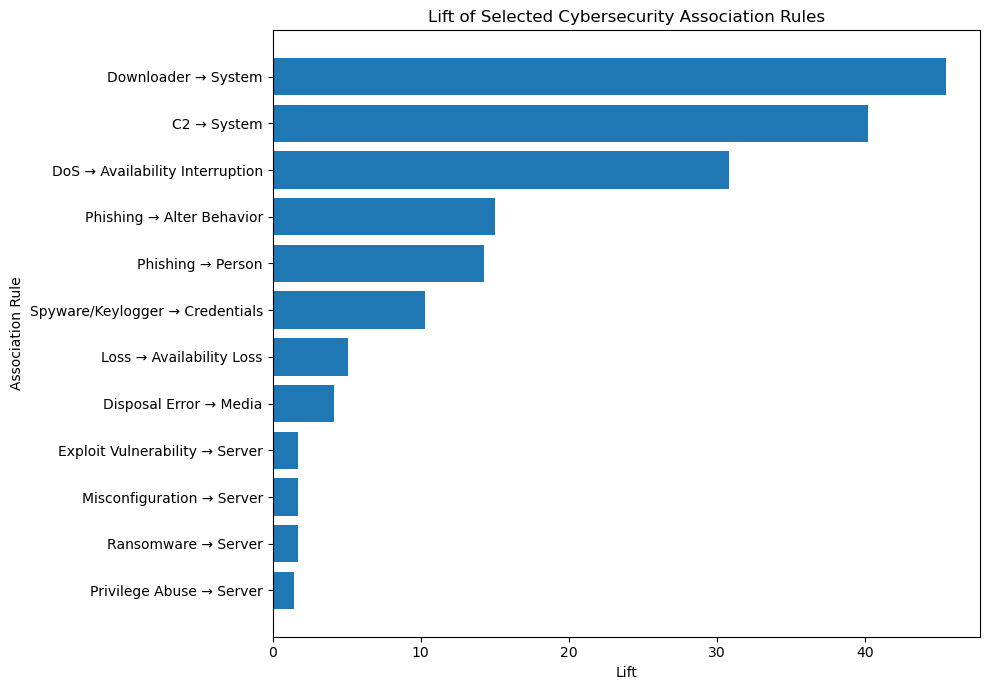

In [46]:
# Step 26: Visualize Lift of the final 12 Apriori rules

import matplotlib.pyplot as plt

# Create readable rule labels
paper_rules["Rule"] = (
    paper_rules["Attack Pattern"]
    + " → "
    + paper_rules["Associated Outcome"]
)

# Sort by lift for visualization
lift_plot = paper_rules.sort_values(
    "Lift",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    lift_plot["Rule"],
    lift_plot["Lift"]
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Lift of Selected Cybersecurity Association Rules")

plt.tight_layout()
plt.show()

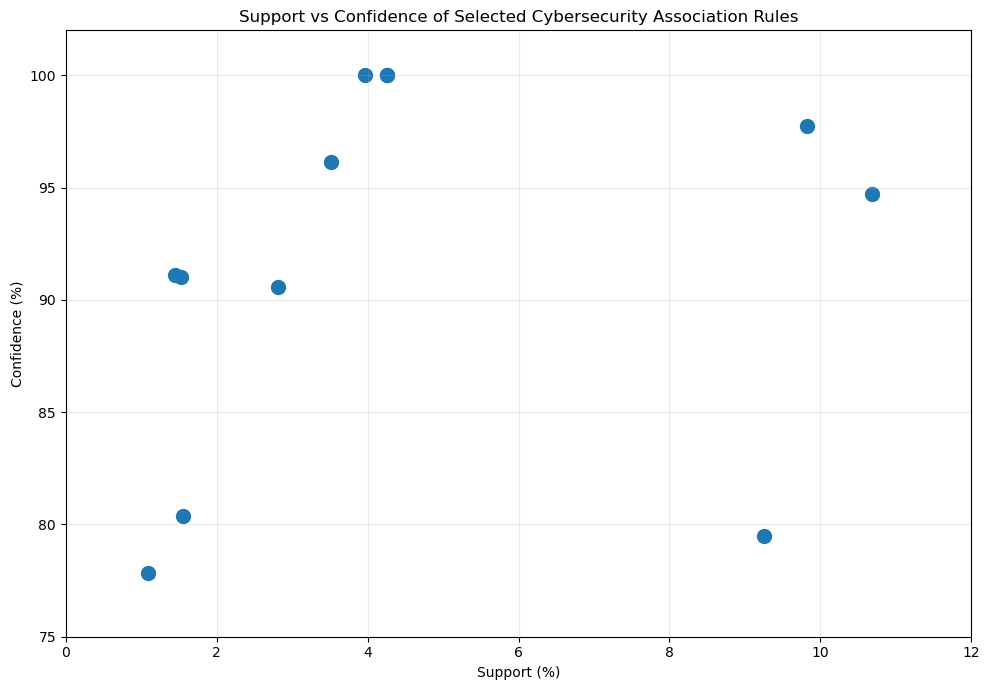

In [49]:
# Step 28: Final clean Support vs Confidence plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    paper_rules["Support (%)"],
    paper_rules["Confidence (%)"],
    s=100
)

plt.xlabel("Support (%)")
plt.ylabel("Confidence (%)")
plt.title("Support vs Confidence of Selected Cybersecurity Association Rules")

plt.xlim(0, 12)
plt.ylim(75, 102)

plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [50]:
# Step 29: Category-wise analysis of final research rules

def get_attack_category(attack):

    if attack in [
        "Phishing",
        "Pretexting",
        "Bribery"
    ]:
        return "Social Engineering"

    elif attack in [
        "DoS",
        "Exploit Vulnerability"
    ]:
        return "Hacking"

    elif attack in [
        "Ransomware",
        "Spyware/Keylogger",
        "Downloader",
        "C2"
    ]:
        return "Malware"

    elif attack in [
        "Privilege Abuse"
    ]:
        return "Misuse"

    elif attack in [
        "Loss",
        "Disposal Error",
        "Misconfiguration"
    ]:
        return "Error"

    else:
        return "Other"


paper_rules["Attack Category"] = (
    paper_rules["Attack Pattern"]
    .apply(get_attack_category)
)

category_summary = (
    paper_rules["Attack Category"]
    .value_counts()
    .reset_index()
)

category_summary.columns = [
    "Attack Category",
    "Number of Rules"
]

print("============================================")
print("CATEGORY-WISE RULE DISTRIBUTION")
print("============================================")

display(category_summary)

CATEGORY-WISE RULE DISTRIBUTION


,Attack Category,Number of Rules
0,Malware,4
1,Error,3
2,Social Engineering,2
3,Hacking,2
4,Misuse,1


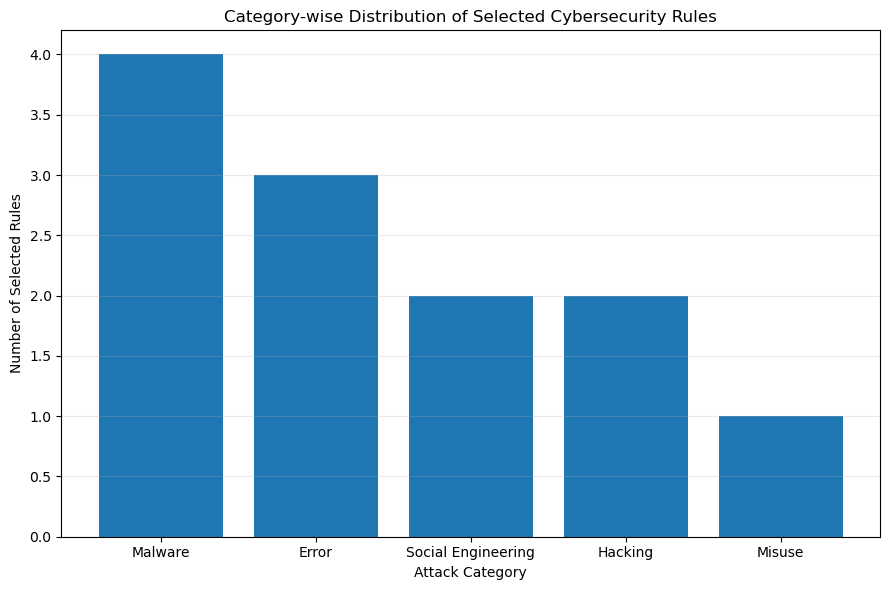

In [51]:
# Step 30: Category-wise distribution of selected rules

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.bar(
    category_summary["Attack Category"],
    category_summary["Number of Rules"]
)

plt.xlabel("Attack Category")
plt.ylabel("Number of Selected Rules")
plt.title("Category-wise Distribution of Selected Cybersecurity Rules")

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [52]:
# Step 31: Consolidated research results dataset

results_df = paper_rules.copy()

# Add percentage of rules represented by each category
category_total = len(results_df)

results_df["Category Share (%)"] = (
    results_df["Attack Category"]
    .map(
        results_df["Attack Category"]
        .value_counts()
        .div(category_total)
        .mul(100)
    )
    .round(2)
)

# Arrange columns
results_df = results_df[
    [
        "Attack Category",
        "Attack Pattern",
        "Associated Outcome",
        "Incident Count",
        "Support (%)",
        "Confidence (%)",
        "Lift",
        "Category Share (%)"
    ]
]

print("============================================")
print("CONSOLIDATED RESEARCH RESULTS")
print("============================================")
print("Total selected rules:", len(results_df))

display(results_df)

CONSOLIDATED RESEARCH RESULTS
Total selected rules: 12


,Attack Category,Attack Pattern,Associated Outcome,Incident Count,Support (%),Confidence (%),Lift,Category Share (%)
0,Social Engineering,Phishing,Alter Behavior,450,4.25,100.00,15.05,16.67
1,Social Engineering,Phishing,Person,450,4.25,100.00,14.30,16.67
2,Hacking,DoS,Availability Interruption,154,1.45,91.12,30.85,16.67
3,Hacking,Exploit Vulnerability,Server,1042,9.83,97.75,1.75,16.67
4,Malware,Ransomware,Server,1133,10.69,94.73,1.69,33.33
5,Misuse,Privilege Abuse,Server,980,9.25,79.48,1.42,8.33
6,Error,Loss,Availability Loss,420,3.96,100.00,5.09,25.00
7,Error,Disposal Error,Media,298,2.81,90.58,4.15,25.00
8,Error,Misconfiguration,Server,373,3.52,96.13,1.72,25.00
9,Malware,Spyware/Keylogger,Credentials,116,1.09,77.85,10.32,33.33


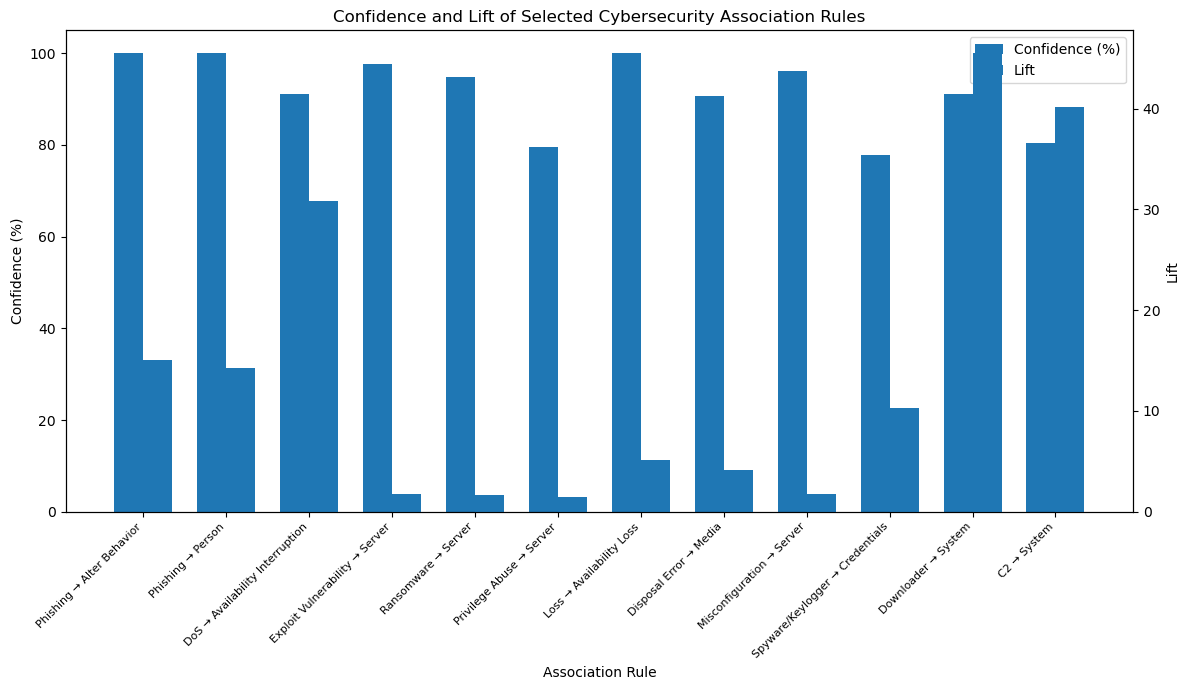

In [53]:
# Step 32: Compare Confidence and Lift of selected rules

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(paper_rules))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 7))

# Confidence
bars1 = ax1.bar(
    x - width/2,
    paper_rules["Confidence (%)"],
    width,
    label="Confidence (%)"
)

ax1.set_xlabel("Association Rule")
ax1.set_ylabel("Confidence (%)")
ax1.set_xticks(x)
ax1.set_xticklabels(
    paper_rules["Rule"],
    rotation=45,
    ha="right",
    fontsize=8
)

# Lift on secondary axis
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    paper_rules["Lift"],
    width,
    label="Lift"
)

ax2.set_ylabel("Lift")

plt.title("Confidence and Lift of Selected Cybersecurity Association Rules")

# Combined legend
ax1.legend(
    [bars1, bars2],
    ["Confidence (%)", "Lift"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [54]:
# Step 33: Final analysis summary

print("============================================")
print("FINAL ANALYSIS SUMMARY")
print("============================================")

print("Total VCDB incidents:", TOTAL_INCIDENTS)
print("Selected attributes:", transaction_df.shape[1])
print("Frequent itemsets:", len(frequent_itemsets))
print("Generated association rules:", len(rules))
print("Meaningful rules:", len(meaningful_rules))
print("Attack-oriented rules:", len(attack_rules))
print("Final research-paper rules:", len(final_12_rules))

print("\nCategory distribution:")
display(category_summary)

print("\nFinal selected rules:")
display(
    results_df[
        [
            "Attack Category",
            "Attack Pattern",
            "Associated Outcome",
            "Incident Count",
            "Support (%)",
            "Confidence (%)",
            "Lift"
        ]
    ]
)

FINAL ANALYSIS SUMMARY
Total VCDB incidents: 10596
Selected attributes: 66
Frequent itemsets: 1183
Generated association rules: 5626
Meaningful rules: 2744
Attack-oriented rules: 1901
Final research-paper rules: 12

Category distribution:


,Attack Category,Number of Rules
0,Malware,4
1,Error,3
2,Social Engineering,2
3,Hacking,2
4,Misuse,1



Final selected rules:


,Attack Category,Attack Pattern,Associated Outcome,Incident Count,Support (%),Confidence (%),Lift
0,Social Engineering,Phishing,Alter Behavior,450,4.25,100.00,15.05
1,Social Engineering,Phishing,Person,450,4.25,100.00,14.30
2,Hacking,DoS,Availability Interruption,154,1.45,91.12,30.85
3,Hacking,Exploit Vulnerability,Server,1042,9.83,97.75,1.75
4,Malware,Ransomware,Server,1133,10.69,94.73,1.69
5,Misuse,Privilege Abuse,Server,980,9.25,79.48,1.42
6,Error,Loss,Availability Loss,420,3.96,100.00,5.09
7,Error,Disposal Error,Media,298,2.81,90.58,4.15
8,Error,Misconfiguration,Server,373,3.52,96.13,1.72
9,Malware,Spyware/Keylogger,Credentials,116,1.09,77.85,10.32
